# Предсказание стоимости акций

## Введение

Этот проект посвящён прогнозированию стоимости открытия акций на следующий день с использованием современных методов машинного обучения. Это уже вторая попытка исследования данной темы: проект базируется на предыдущих наработках, но значительно расширен. Добавлены новые признаки, исследуется большее количество моделей, что позволяет более глубоко изучить и оценить возможности прогнозирования.

Проект разработан как открытая инициатива и доступен на GitHub, чтобы продемонстрировать комплексный подход к анализу данных и моделированию. Здесь исследуются временные ряды, создаются новые признаки, проводится их анализ, а также тестируются подходы для оценки прибыльности стратегий. Основная цель — разработать модель, способную не только показывать хорошие метрики точности, но и быть полезной для практического применения на реальных рыночных данных.

**Этапы проекта**

Данный проект направлен на предсказание стоимости акций и включает в себя несколько ключевых этапов:

1. **Исследование данных и их подготовка:**
   - Анализ структуры данных, проверка на наличие пропусков и дубликатов.
   - Добавление новых признаков, включая трендовые, сезонные и лаговые переменные, для повышения точности модели.
   - Проверка данных на мультиколлинеарность и избыточность признаков.

2. **Разделение данных:**
   - Корректное разделение данных на тренировочную и тестовую выборки с учетом временной структуры.
   - Использование данных за последние 10 лет для обучения модели.
   
3. **Визуализация данных:**
   - Построение графиков для анализа трендов, волатильности и других рыночных характеристик.
   - Сравнение данных между тренировочной и тестовой выборками.

4. **Обучение моделей:**
   - Тестирование различных моделей, включая линейную регрессию, градиентный бустинг, рекуррентные нейронные сети и другие подходы.
   - Настройка гиперпараметров и использование кросс-валидации для оценки производительности.

5. **Оценка метрик:**
   - Выбор метрики для оценки качества модели, таких как MAPE, RMSE и другие.
   - Анализ результатов предсказаний и их сравнение с реальными данными.

6. **Оценка прибыльности:**
   - Разработка подхода для оценки прибыльности стратегии, основанной на предсказаниях модели.
   - Внедрение симуляции торговли для проверки эффективности предложенных решений.

7. **Выводы и перспективы:**
   - Итоговый анализ результатов проекта.
   - Определение сильных и слабых сторон модели.
   - Обсуждение возможных путей улучшения, включая добавление новых данных или использование ансамблевых стратегий.

---

**Статус проекта:**

На данный момент проект находится на этапе активной разработки. Новые признаки уже добавлены, проводится исследование данных и предварительное тестирование моделей. В будущем планируется:
- Оценка прибыльности различных стратегий.
- Усовершенствование метрик для лучшей интерпретации результатов.
- Публикация итогов исследования, включая перевод на английский и описание подходов, для доступности более широкой аудитории.

Далее следуют этапы проекта, начиная с загрузки данных.

## Загрузка данных

In [1]:
# Загрузка необходимых библиотек
import warnings
import inspect
import re
import os

import pandas as pd
import numpy as np
import yfinance as yf

import matplotlib.pyplot as plt
import seaborn as sns

import optuna
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import make_scorer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

In [2]:
# настройки
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
optuna.logging.disable_default_handler()

# константы
NAME="apple"
TARGET = "Open"
# START_DATE = "2019-01-01"
# START_DATE = "2019-12-13" # последние 5 лет
START_DATE = "2014-10-22" # последние 10 лет с учётом удаления пустых сторок при создании новых переменных
END_DATE = "2025-01-01"
RANDOM_STATE = 42
TEST_SIZE = 0.2
N_TRAILS = 50

# используемые акции и их тикеты
name_of_stocks = {"apple": "AAPL",
                 "microsoft": "MSFT",
                 "nvidia": "NVDA",
                 "google": "GOOG"}

### Functions

In [3]:
# функция для просмотра данных        
def data_review(data):
    print('ПЕРВЫЕ 5 СТРОЧЕК С ДАННЫМИ:')
    display(data.head())
    print(f'\nОБЩАЯ ИНФОРМАЦИЯ О ДАННЫХ:\n')
    data.info()
    print(f'\n\nКОЛИЧЕСТВО ПРОПУСКОВ В ДАННЫХ:\n\n{data.isna().sum()}\n')
    print(f'\nКОЛИЧЕСТВО ДУБЛИКАТОВ В ДАННЫХ - {data.duplicated().sum()}\n')
    print('\nСТАТИСТИКА ПО ЧИСЛОВЫМ СТОЛБЦАМ:')
    display(data.describe())

In [4]:
def download_and_merge_stocks(stock_dict, start_date, end_date):
    """Function for downloding data and merging all list of stocks"""
    # Создаем пустой список для хранения отдельных DataFrame
    merged_data = []

    for name, ticker in stock_dict.items():
        # Загружаем данные
        stock_data = yf.download(ticker, start=start_date, end=end_date, progress=False)
        
        # Переименовываем столбцы
        stock_data = stock_data.add_suffix(f"_{name}")
        stock_data = stock_data.rename(columns={f'Adj Close_{name}': f'Adj_Close_{name}'})
        
        # Добавляем полученные данные в список
        merged_data.append(stock_data)
    
    # Объединяем все данные по индексу (дата)
    merged_df = pd.concat(merged_data, axis=1)
    
    return merged_df

### Загрузка и первичное знакомство с данными

In [5]:
data = download_and_merge_stocks(name_of_stocks, START_DATE, END_DATE)

# Просмотр первых строк объединенного DataFrame
data_review(data)

ПЕРВЫЕ 5 СТРОЧЕК С ДАННЫМИ:


,Open_apple,High_apple,Low_apple,Close_apple,Adj_Close_apple,Volume_apple,Open_microsoft,High_microsoft,Low_microsoft,Close_microsoft,...,Low_nvidia,Close_nvidia,Adj_Close_nvidia,Volume_nvidia,Open_google,High_google,Low_google,Close_google,Adj_Close_google,Volume_google
Date,,,,,,,,,,,,,,,,,,,,,
2014-10-22,25.709999,26.027500,25.650000,25.747499,22.836269,273052400,45.000000,45.070000,44.230000,44.380001,...,0.44725,0.44725,0.427571,239512000,26.421959,26.916101,26.367607,26.562572,26.467470,58385859
2014-10-23,26.020000,26.262501,25.907499,26.207500,23.244253,284298800,44.619999,45.450001,44.529999,45.020000,...,0.45175,0.45725,0.437131,214476000,26.892168,27.286085,26.719143,27.124531,27.027418,46976621
2014-10-24,26.295000,26.372499,26.132500,26.305000,23.330730,188215600,46.830002,46.900002,45.180000,46.130001,...,0.45725,0.46200,0.441673,210156000,27.143478,27.169407,26.716150,26.915106,26.818743,39462046
2014-10-27,26.212500,26.370001,26.174999,26.277500,23.306343,136750800,45.709999,46.099998,45.709999,45.910000,...,0.45675,0.46225,0.441911,145092000,26.777981,27.145971,26.777981,26.964470,26.867931,23706909
2014-10-28,26.350000,26.684999,26.337500,26.684999,23.667765,192243600,45.860001,46.500000,45.770000,46.490002,...,0.46050,0.47325,0.452427,192580000,27.075665,27.373844,27.006853,27.369856,27.271864,25419598



ОБЩАЯ ИНФОРМАЦИЯ О ДАННЫХ:

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2565 entries, 2014-10-22 to 2024-12-31
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Open_apple           2565 non-null   float64
 1   High_apple           2565 non-null   float64
 2   Low_apple            2565 non-null   float64
 3   Close_apple          2565 non-null   float64
 4   Adj_Close_apple      2565 non-null   float64
 5   Volume_apple         2565 non-null   int64  
 6   Open_microsoft       2565 non-null   float64
 7   High_microsoft       2565 non-null   float64
 8   Low_microsoft        2565 non-null   float64
 9   Close_microsoft      2565 non-null   float64
 10  Adj_Close_microsoft  2565 non-null   float64
 11  Volume_microsoft     2565 non-null   int64  
 12  Open_nvidia          2565 non-null   float64
 13  High_nvidia          2565 non-null   float64
 14  Low_nvidia           2565 non-null   floa

,Open_apple,High_apple,Low_apple,Close_apple,Adj_Close_apple,Volume_apple,Open_microsoft,High_microsoft,Low_microsoft,Close_microsoft,...,Low_nvidia,Close_nvidia,Adj_Close_nvidia,Volume_nvidia,Open_google,High_google,Low_google,Close_google,Adj_Close_google,Volume_google
count,2565.000000,2565.000000,2565.000000,2565.000000,2565.000000,2.565000e+03,2565.000000,2565.000000,2565.000000,2565.000000,...,2565.000000,2565.000000,2565.000000,2.565000e+03,2565.000000,2565.000000,2565.000000,2565.000000,2565.000000,2.565000e+03
mean,94.969516,95.979217,94.031226,95.056499,92.957010,1.184377e+08,184.982043,186.739201,183.139520,185.025559,...,20.027484,20.431845,20.402239,4.628067e+08,81.670660,82.546503,80.865380,81.720629,81.447403,3.088392e+07
std,65.224624,65.900321,64.615659,65.304638,65.796607,6.891987e+07,123.208111,124.284286,122.029547,123.209389,...,31.489351,32.124977,32.129882,2.538201e+08,44.766747,45.274666,44.312405,44.788051,44.668312,1.536051e+07
min,22.500000,22.917500,22.367500,22.584999,20.697264,2.323470e+07,40.340000,40.740002,39.720001,40.290001,...,0.447250,0.447250,0.427571,4.564400e+07,24.664783,24.730902,24.311253,24.560070,24.472139,6.809800e+06
25%,36.112499,36.365002,35.862499,36.072498,33.664791,7.144740e+07,68.610001,68.879997,68.089996,68.459999,...,2.947500,3.032250,2.991605,2.999160e+08,45.515499,45.962250,45.306499,45.585499,45.422295,2.127200e+07
50%,63.900002,64.669998,62.349998,64.282501,62.134224,1.016724e+08,146.740005,149.600006,144.729996,147.309998,...,6.242750,6.331250,6.289898,4.119080e+08,62.648499,63.450001,62.131001,63.064499,62.838715,2.709600e+07
75%,151.279999,153.490005,150.059998,151.600006,149.715591,1.450228e+08,282.079987,284.950012,278.529999,281.399994,...,20.511000,20.716000,20.679073,5.570490e+08,120.220497,121.406998,119.161850,120.168503,119.738274,3.591460e+07
max,258.190002,260.100006,257.630005,259.019989,259.019989,6.488252e+08,467.000000,468.350006,464.459991,467.559998,...,146.259995,148.880005,148.869751,3.692928e+09,198.529999,202.880005,196.690002,198.160004,198.160004,2.232980e+08


Краткие пояснения, что за собой скрывают названия столбцов:

1. **Date**: Дата торгового дня.

2. **Open**: Цена открытия акций в начале торгового дня.

3. **High**: Самая высокая цена, достигнутая акциями в течение торгового дня.

4. **Low**: Самая низкая цена, достигнутая акциями в течение торгового дня.

5. **Close**: Цена закрытия акций в конце торгового дня (без учета корпоративных действий).

6. **Adj Close**: Скорректированная цена закрытия, которая учитывает все корпоративные действия, такие как выплата дивидендов, разделение акций и т. д.

7. **Volume**: Объем торгов, показывающий количество акций, которые были куплены и проданы в течение торгового дня.

## Анализ данных

### Functions

In [6]:
# Feature engenering
def new_features(df, name=NAME, sma_periods=[3, 5, 10, 20, 50], target=TARGET, max_lag=13):
    """
    Enhances the dataset by adding:
    - Moving Averages (SMA, EMA) and Volatility for specified periods.
    - Percentage changes in volume and price.
    - Basic differences (Open, High, Low, Close, Adjusted Close).
    - Trend and seasonality features (day of the week, week number, month, year, quarter).
    - Lag features for the target column (up to `max_lag`).
    - Trend indicators: RSI and MACD.
    - Feature interactions: High/Low ratio, Close/Open ratio, Volume/Price ratio, and Volume * Volatility.
    - Target features: next day's target price and future low value.
    - Removes rows with NaN values caused by rolling calculations and shifts.

    Parameters:
    - `df`: Input DataFrame.
    - `name`: Identifier for the stock (default: NAME).
    - `sma_periods`: Periods for moving averages and volatility.
    - `target`: Target column to predict.
    - `max_lag`: Maximum lag features.

    Returns:
    - Updated DataFrame with new features.
    """
    # Приведение всех столбцов к общему виду
    target_col = f'{target}_{name}'
    
    # Скользящие средние (SMA и EMA) и Волатильность
    for period in sma_periods:
        df[f'SMA_{period}_{name}'] = df[target_col].rolling(window=period).mean()
        df[f'EMA_{period}_{name}'] = df[target_col].ewm(span=period, adjust=False).mean()
        df[f'Volatility_{period}_{name}'] = df[target_col].rolling(window=period).std()
    
    # Процентные изменения
    df[f'Volume_Change_{name}'] = df[f'Volume_{name}'].pct_change()
    df[f'Price_Change_{name}'] = df[target_col].pct_change()
    
    # Создание базовых признаков (на базе разности)
    df[f'Open_High_{name}'] = df[f'Open_{name}'] - df[f'High_{name}']
    df[f'Open_Low_{name}'] = df[f'Open_{name}'] - df[f'Low_{name}']
    df[f'High_Low_{name}'] = df[f'High_{name}'] - df[f'Low_{name}']
    df[f'High_Close_{name}'] = df[f'High_{name}'] - df[f'Close_{name}']
    df[f'Low_Close_{name}'] = df[f'Low_{name}'] - df[f'Close_{name}']
    df[f'Close_Open_{name}'] = df[f'Close_{name}'] - df[f'Open_{name}']
    df[f'AdjClose_Open_{name}'] = df[f'Adj_Close_{name}'] - df[f'Open_{name}']
    df[f'AdjClose_Low_{name}'] = df[f'Adj_Close_{name}'] - df[f'Low_{name}']
    df[f'AdjClose_High_{name}'] = df[f'Adj_Close_{name}'] - df[f'High_{name}']
    df[f'AdjClose_Close_{name}'] = df[f'Adj_Close_{name}'] - df[f'Close_{name}']
    
    # Добавление признаков тренда и сезонности
    df[f'Day_of_Week_{name}'] = df.index.dayofweek
    df[f'Number_of_Week_{name}'] = df.index.isocalendar().week
    df[f'Month_{name}'] = df.index.month
    df[f'Year_{name}'] = df.index.year
    df[f'Quarter_{name}'] = df.index.quarter
    
    # Добавление лаг-функций
    for lag in range(1, max_lag):
        df[f'Lag_{lag}_{name}'] = df[target_col].shift(lag)
    
    # Индикаторы тренда
    df[f'RSI_{name}'] = 100 - (100 / (1 + df[target_col].diff().clip(lower=0).rolling(window=14).mean() /
                                          df[target_col].diff().clip(upper=0).abs().rolling(window=14).mean()))
    df[f'MACD_{name}'] = df[target_col].ewm(span=12, adjust=False).mean() - df[target_col].ewm(span=26, adjust=False).mean()
    
    # Взаимодействия между переменными
    df[f'High_Low_Ratio_{name}'] = df[f'High_{name}'] / df[f'Low_{name}']
    df[f'Close_Open_Ratio_{name}'] = df[f'Close_{name}'] / df[f'Open_{name}']
    df[f'Volume_to_Price_{name}'] = df[f'Volume_{name}'] / df[target_col]
    df[f'Volume_Volatility_{name}'] = df[f'Volume_{name}'] * df[f'Volatility_{10}_{name}']


    # Добавляем столбец с ценой таргета на следующий день и будущих данных
    df['Target'] = df[target_col].shift(-1)
    df['Low_future'] = df[f'Low_{name}'].shift(-1)
    
    # Удаление строк с NaN значениями, которые появились из-за использования скользящих средних и других вычислений
    df.dropna(inplace=True)
    
    return df

In [7]:
# Деление данных по годам
def split_data_by_year_column(df, test_size=TEST_SIZE, company=NAME):
    """
    Делит данные на тренировочную и тестовую выборки по годам, основываясь на размере тестовой выборки.
    
    :param df: DataFrame с данными.
    :param test_size: Пропорция тестовых данных (например, 0.2).
    :param company: Название компании (например, "apple").
    :return: Два DataFrame: train_data, test_data.
    """
    # Получаем список уникальных годов
    unique_years = sorted(df[f'Year_{company}'].unique())
    
    # Вычисляем количество лет для тестовой выборки
    test_years_count = int(len(unique_years) * test_size)
    
    # Определяем года для train и test
    train_years = unique_years[:-test_years_count]
    test_years = unique_years[-test_years_count:]
    
    # Делим данные
    train_data = df[df[f'Year_{company}'].isin(train_years)]
    test_data = df[df[f'Year_{company}'].isin(test_years)]
    
    return train_data, test_data

In [8]:
# Визуализация данных
# Визуализация данных
class StockDataVisualizer:
    def __init__(self, data, label_suffix=None):
        """
        Инициализация класса.
        
        :param data: DataFrame с данными о ценах акций.
        :param label_suffix: Суффикс для добавления в заголовки графиков (например, "train" или "test").
        """
        self.data = data
        self.label_suffix = f"({label_suffix})" if label_suffix else ""

    def _finalize_plot(self, title, xlabel, ylabel):
        """
        Вспомогательный метод для настройки графиков.
        """
        plt.title(title)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.legend(loc='upper left')
        plt.grid(True)
        plt.show()

    def plot_aggregated(self, companies, targets, group_by=None, agg_func=None, 
                        title='Aggregated Data', ylabel='Value', xlabel='Date', 
                        secondary_metric=None, secondary_axis=False):
        """
        Универсальный метод для построения графиков.
        """
        plt.figure(figsize=(12, 6))
        for company in companies:
            for target in targets:
                column = f'{target}_{company}'
                if group_by and agg_func:
                    grouped = self.data[column].resample(group_by).agg(agg_func)
                    plt.plot(grouped, label=f'{company.capitalize()} {target} ({agg_func})')
                else:
                    plt.plot(self.data[column], label=f'{company.capitalize()} {target}')

        if secondary_axis and secondary_metric:
            ax2 = plt.gca().twinx()
            for company in companies:
                secondary_column = f'{secondary_metric}_{company}'
                ax2.plot(self.data[secondary_column], linestyle='--', alpha=0.7, label=f'{secondary_metric} ({company})')
            ax2.set_ylabel(secondary_metric, color='red')
            ax2.tick_params(axis='y', labelcolor='red')

        self._finalize_plot(title, xlabel, ylabel)

    def plot_last_years(self, companies, targets=['Close'], group_by=None, agg_func=None, 
                        title='Last Years Analysis', ylabel='Value', xlabel='Date', 
                        secondary_metric=None, secondary_axis=False, years=2):
        """
        Построение графика за последние N лет.
        """
        end_date = self.data.index.max()
        start_date = end_date - pd.DateOffset(years=years)
        filtered_data = self.data[(self.data.index >= start_date) & (self.data.index <= end_date)]
        visualizer = StockDataVisualizer(data=filtered_data, label_suffix=self.label_suffix)
        visualizer.plot_aggregated(
            companies=companies,
            targets=targets,
            group_by=group_by,
            agg_func=agg_func,
            title=title,
            ylabel=ylabel,
            xlabel=xlabel,
            secondary_metric=secondary_metric,
            secondary_axis=secondary_axis
        )

    def plot_time_series(self, columns, labels, title, ylabel, xlabel='Date', figsize=(12, 6)):
        """
        Построение графиков временных рядов.
        """
        plt.figure(figsize=figsize)
        for col, label in zip(columns, labels):
            plt.plot(self.data.index, self.data[col], label=label)
        self._finalize_plot(title, xlabel, ylabel)

    def plot_correlation_heatmap(self, columns, title='Correlation Heatmap', figsize=(8, 6)):
        """
        Построение тепловой карты корреляции.
        """
        corr = self.data[columns].corr()
        plt.figure(figsize=figsize)
        sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
        plt.title(title)
        plt.show()

    def plot_grouped_bar(self, group_by_column, value_column, agg_func='mean', 
                         title='', xlabel='', ylabel='', figsize=(10, 6)):
        """
        Построение сгруппированных столбчатых диаграмм.
        """
        grouped_data = self.data.groupby(group_by_column)[value_column].agg(agg_func)
        grouped_data.plot(kind='bar', figsize=figsize)
        self._finalize_plot(title, xlabel, ylabel)


In [9]:
# Визуализация данных одновременно нескольких экземпляров класса
def process_multiple_instances(instances, method_name, **kwargs):
    """
    Обработка нескольких экземпляров класса `StockDataVisualizer`.

    :param instances: Список экземпляров класса `StockDataVisualizer`.
    :param method_name: Название метода для вызова.
    :param kwargs: Аргументы для метода.
    """
    for i, instance in enumerate(instances):
        method = getattr(instance, method_name)
        data_type = "Training Data" if i == 0 else "Test Data"
        if 'title' in kwargs:
            kwargs['title'] = f"{kwargs['title']} ({data_type})"
        method(**kwargs)

### Feature engineering

На этапе **feature engineering** создаются дополнительные признаки, которые обогащают исходные данные для улучшения предсказательной способности модели. Добавленные признаки помогут выявить скрытые закономерности, связанные с трендами, волатильностью, сезонностью и историческими данными. 

Особое внимание уделяется тому, чтобы избежать утечек данных. Все создаваемые признаки основаны исключительно на исторической информации, доступной на момент предсказания. Например:
- Лаговые признаки (`Lag_1`, `Lag_2`, и т.д.) содержат информацию о предыдущих значениях целевой переменной.
- Признаки трендов (скользящие средние `SMA`, экспоненциальные средние `EMA`) и волатильность рассчитываются на основе доступных данных за предшествующие периоды.
- Переменная `df['Low_future']` добавлена для дополнительного анализа, но **не будет использоваться для обучения модели**, чтобы исключить риск утечки данных.

Эти меры гарантируют, что модель будет работать корректно и надежно при предсказании на тестовых данных и новых наблюдениях.


In [10]:
# Add new features
data = new_features(data)

На этом этапе реализуется генерация дополнительных признаков для обогащения данных с целью предсказания **цены открытия акций компании Apple на следующий день**. Ниже представлен структурированный разбор добавленных признаков.

---

**1. Базовые признаки: разности между основными показателями**

Эти признаки учитывают внутридневную и междневную динамику цен, что важно для анализа волатильности и колебаний рынка. Они созданы как для целевой переменной, так и для других компаний.

**Признаки**:
- `Open_High`: Разница между ценой открытия (`Open`) и максимальной ценой (`High`).
- `Open_Low`: Разница между ценой открытия и минимальной ценой (`Low`).
- `High_Low`: Дневной диапазон цен (разница между `High` и `Low`).
- `High_Close`: Разница между максимальной ценой и ценой закрытия (`Close`).
- `Low_Close`: Разница между минимальной ценой и ценой закрытия.
- `Close_Open`: Разница между ценой закрытия и ценой открытия.
- `AdjClose_Open`: Разница между скорректированной ценой закрытия (`Adj Close`) и ценой открытия.
- `AdjClose_Low`: Разница между скорректированной ценой закрытия и минимальной ценой.
- `AdjClose_High`: Разница между скорректированной ценой закрытия и максимальной ценой.
- `AdjClose_Close`: Разница между скорректированной ценой закрытия и ценой закрытия.

Эти признаки создают основу для анализа поведения акций, помогая модели учитывать волатильность и тренды.

---

**2. Скользящие средние (SMA, EMA) и волатильность**

Эти признаки выявляют краткосрочные тренды и уровень риска, сглаживая временные ряды.

**Признаки**:
- **SMA** (Simple Moving Average): Среднее значение за последние 3, 5, 10, 20 и 50 дней.
- **EMA** (Exponential Moving Average): Похоже на SMA, но с большим весом для недавних данных.
- **Волатильность** (Volatility): Стандартное отклонение цены открытия за последние 3, 5, 10, 20 и 50 дней.

---

**3. Процентные изменения**

Эти признаки оценивают динамику рынка и активности.

**Признаки**:
- `Volume_Change`: Процентное изменение объёма торговли.
- `Price_Change`: Процентное изменение цены открытия относительно предыдущего дня.

---

**4. Признаки тренда и сезонности**

Эти признаки учитывают временные закономерности, влияющие на рынок.

**Признаки**:
- `Day_of_Week`: День недели (например, понедельник = 0).
- `Number_of_Week`: Номер недели года.
- `Month`: Месяц.
- `Year`: Год.
- `Quarter`: Квартал.

---

**5. Лаг-функции**

Лаг-признаки предоставляют исторический контекст для предсказания.

**Признаки**:
- `Lag_1`, `Lag_2`, ..., `Lag_12`: Значения цены открытия за предыдущие 12 дней.

---

**6. Индикаторы тренда**

Эти признаки помогают оценить направление движения рынка.

**Признаки**:
- `RSI` (Relative Strength Index): Индикатор силы тренда.
- `MACD` (Moving Average Convergence Divergence): Разница между экспоненциальными скользящими средними с периодами 12 и 26.

---

**7. Взаимодействия между переменными**

Дополнительные признаки, оценивающие соотношения между основными показателями.

**Признаки**:
- `High_Low_Ratio`: Соотношение максимальной и минимальной цен.
- `Close_Open_Ratio`: Соотношение цены закрытия и цены открытия.
- `Volume_to_Price`: Соотношение объёма торгов к цене открытия.
- `Volume_Volatility`: Произведение объёма торгов и волатильности за 10 дней.

---

**8. Целевая переменная**

Определяет метрику, которую нужно предсказать.

**Признаки**:
- `Target`: Цена открытия на следующий день.
- `Low_future`: Минимальная цена на следующий день.

---

**9. Удаление строк с пропусками**

Строки с `NaN`, возникшие из-за скользящих средних, лагов и других вычислений, удаляются для обеспечения корректности данных.


In [11]:
data_review(data)

ПЕРВЫЕ 5 СТРОЧЕК С ДАННЫМИ:


,Open_apple,High_apple,Low_apple,Close_apple,Adj_Close_apple,Volume_apple,Open_microsoft,High_microsoft,Low_microsoft,Close_microsoft,...,Lag_11_apple,Lag_12_apple,RSI_apple,MACD_apple,High_Low_Ratio_apple,Close_Open_Ratio_apple,Volume_to_Price_apple,Volume_Volatility_apple,Target,Low_future
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,27.847500,27.860001,26.837500,27.332500,24.347164,212818400,46.660000,47.419998,46.540001,46.759998,...,26.592501,27.674999,47.667553,0.021011,1.038100,0.981506,7.642280e+06,4.158075e+07,27.072500,26.352501
2015-01-05,27.072500,27.162500,26.352501,26.562500,23.661272,257142000,46.369999,46.730000,46.250000,46.330002,...,26.780001,26.592501,44.561407,-0.062009,1.030737,0.981162,9.498273e+06,1.008371e+08,26.635000,26.157499
2015-01-06,26.635000,26.857500,26.157499,26.565001,23.663504,263188400,46.380001,46.750000,45.540001,45.650002,...,27.967501,26.780001,40.307558,-0.161247,1.026761,0.997372,9.881299e+06,1.569378e+08,26.799999,26.674999
2015-01-07,26.799999,27.049999,26.674999,26.937500,23.995316,160423600,45.980000,46.459999,45.490002,46.230000,...,28.065001,27.967501,52.332755,-0.223997,1.014058,1.005131,5.985955e+06,1.105026e+08,27.307501,27.174999
2015-01-08,27.307501,28.037500,27.174999,27.972500,24.917274,237458000,46.750000,47.750000,46.720001,47.590000,...,28.040001,28.065001,55.532249,-0.230123,1.031739,1.024352,8.695706e+06,1.609394e+08,28.167500,27.552500



ОБЩАЯ ИНФОРМАЦИЯ О ДАННЫХ:

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2515 entries, 2015-01-02 to 2024-12-30
Data columns (total 76 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Open_apple               2515 non-null   float64
 1   High_apple               2515 non-null   float64
 2   Low_apple                2515 non-null   float64
 3   Close_apple              2515 non-null   float64
 4   Adj_Close_apple          2515 non-null   float64
 5   Volume_apple             2515 non-null   int64  
 6   Open_microsoft           2515 non-null   float64
 7   High_microsoft           2515 non-null   float64
 8   Low_microsoft            2515 non-null   float64
 9   Close_microsoft          2515 non-null   float64
 10  Adj_Close_microsoft      2515 non-null   float64
 11  Volume_microsoft         2515 non-null   int64  
 12  Open_nvidia              2515 non-null   float64
 13  High_nvidia              2515 n

,Open_apple,High_apple,Low_apple,Close_apple,Adj_Close_apple,Volume_apple,Open_microsoft,High_microsoft,Low_microsoft,Close_microsoft,...,Lag_11_apple,Lag_12_apple,RSI_apple,MACD_apple,High_Low_Ratio_apple,Close_Open_Ratio_apple,Volume_to_Price_apple,Volume_Volatility_apple,Target,Low_future
count,2515.000000,2515.000000,2515.000000,2515.000000,2515.000000,2.515000e+03,2515.000000,2515.000000,2515.000000,2515.000000,...,2515.000000,2515.000000,2515.000000,2515.000000,2515.000000,2515.000000,2.515000e+03,2.515000e+03,2515.000000,2515.000000
mean,96.213553,97.237679,95.262663,96.302716,94.221354,1.171176e+08,187.562553,189.347066,185.693395,187.609129,...,95.233388,95.146225,55.480030,0.593041,1.020234,1.000832,2.474010e+06,2.042498e+08,96.302854,95.351169
std,65.113471,65.788868,64.507420,65.195818,65.676524,6.839566e+07,122.819133,123.890378,121.648088,122.822609,...,64.443388,64.386407,17.272961,2.109577,0.012208,0.013824,2.704919e+06,2.285190e+08,65.173654,64.566176
min,22.500000,22.917500,22.367500,22.584999,20.697264,2.323470e+07,40.340000,40.740002,39.720001,40.290001,...,22.500000,22.500000,9.891947,-6.687963,1.004394,0.927421,9.094172e+04,8.326683e+06,22.500000,22.367500
25%,37.593750,38.012501,37.293751,37.638750,35.362555,7.108210e+07,70.865002,71.494999,70.294998,71.010002,...,37.125000,37.056250,42.879182,-0.385849,1.012368,0.993593,5.025054e+05,6.806032e+07,37.632500,37.301250
50%,66.449997,67.062500,65.752502,66.592499,64.664894,1.003845e+08,151.860001,155.479996,150.910004,153.240005,...,65.647499,65.387497,56.662563,0.405027,1.017207,1.000942,1.606491e+06,1.370038e+08,66.650002,65.862503
75%,152.475006,154.549995,150.790001,152.665001,150.899132,1.426222e+08,283.785004,286.889999,280.125000,283.354996,...,151.345001,151.245003,68.979497,1.498293,1.024536,1.008577,3.582013e+06,2.540604e+08,152.575005,150.825005
max,258.190002,260.100006,257.630005,259.019989,259.019989,6.488252e+08,467.000000,468.350006,464.459991,467.559998,...,247.960007,247.960007,96.485864,9.089833,1.182609,1.086961,2.735639e+07,2.363190e+09,258.190002,257.630005


Создание новых признаков позволяет учитывать как краткосрочные тренды и волатильность, так и сезонные закономерности, обеспечивая более полное представление о динамике цен и их взаимосвязях. Это может сделать модель более информативной и эффективной для предсказания цены открытия акций.

### Общий анализ данных

Вернёмся к общей информации по представленным данным и проведём их общий анализ. Этот этап направлен на первичное исследование данных, выявление ключевых характеристик и подготовку их к дальнейшей работе.

---

**1. Общая информация**

Данные охватывают период с **2 января 2015 года** по **30 декабря 2024 года** и включают:
- **2515 записей**,
- **76 столбцов**, большая часть которых представлена в формате `float64`, а также `int32` и `int64`,
- Пропуски и дубликаты **отсутствуют**, что упрощает их анализ и подготовку к моделированию.

Включённые данные содержат:
- **Цены акций**: открытие, закрытие, максимальные и минимальные значения.
- **Объёмы торгов** для компаний Apple, Microsoft, Nvidia и Google.
- **Дополнительные признаки**: скользящие средние, волатильность, лаги, показатели сезонности и другие преобразованные переменные.

Эти данные представляют собой богатый набор информации для анализа и разработки прогнозной модели.

---

**2. Статистическая сводка**

**Основные показатели (Apple):**
- **Цена открытия**:
  - Среднее значение: ~96.21.
  - Диапазон: от **22.50** до **258.19**.
- **Цена закрытия**:
  - Среднее значение: ~96.30.
  - Диапазон: от **22.58** до **259.02**.
- **Объём торгов**:
  - Среднее значение: ~117.12 млн акций.
  - Максимальный объём: ~648.83 млн акций.

**Другие компании:**
Microsoft, Nvidia и Google демонстрируют схожие закономерности, включая рост цен к концу временного ряда. Это отражает общий рост рынка и высокую популярность данных компаний.

**Дополнительные признаки:**
- **Скользящие средние** (`SMA`, `EMA`) и **волатильность** дают представление о долгосрочных и краткосрочных трендах.
- Лаговые признаки (`Lag_1_apple`, `Lag_2_apple` и др.) помогают учесть историческую зависимость данных.
- **Индикаторы, такие как RSI и MACD**, добавляют информацию о рыночных условиях и помогают выявить перекупленность или перепроданность актива.

---

**3. Наблюдения**

- **Минимальные значения цен акций** отмечаются в начале временного ряда, что соответствует росту компаний с 2015 года.
- **Максимальные значения цен** фиксируются ближе к 2024 году, отражая общие экономические и рыночные тренды.
- **Волатильность** остаётся значительной, особенно в периоды глобальных экономических событий, таких как кризис 2020 года.
- Добавленные признаки (например, отношения `Volume_to_Price` и `Close_Open_Ratio`) могут оказаться полезными для учёта аномалий или ключевых изменений в тренде.

---

**Промежуточные выводы**

- Данные подготовлены к дальнейшему анализу, осталось только разделение на тренировочную и тестовую выборки, а также обучение моделей.
- **Трендовые признаки** (скользящие средние `SMA` и `EMA`) обеспечивают информацию о долгосрочных тенденциях.
- **Сезонные признаки** (день недели, месяц, квартал) позволяют учесть временные закономерности.
- **Индикаторы и исторические значения** (например, RSI, MACD, лаги) обеспечивают более глубокую связь с динамикой рынка.

На следующем этапе:
- Разделим данные на тренировочную и тестовую выборки для корректного обучения модели и предотвращения утечки данных.
- Проведём проверку на мультиколлинеарность и удалим избыточные признаки, чтобы улучшить качество модели.

---

Для разделения данных мы использовали подход, основанный на годах, вместо стандартного метода `train_test_split`. Это решение обусловлено задачей временных рядов, где важно сохранить хронологический порядок данных и исключить возможные утечки информации.

Тренировочная выборка включает данные первых **8 полных лет**, а тестовая — последние **2 полных года**. Такой подход позволяет сохранить однородность данных, предоставляя модели для обучения и тестирования строго разделённые и последовательные временные интервалы. Это особенно важно для временных рядов, где закономерности могут изменяться в течение года, а использование ровных периодов обеспечивает более чистое и корректное обучение.


In [12]:
# Разделение данных на train и test
# train_data, test_data = train_test_split(data, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=False)
train_data, test_data = split_data_by_year_column(data, test_size=TEST_SIZE,  company=NAME)


# Отображение размеров выборок в процентном соотношении
total_size = train_data.shape[0] + test_data.shape[0]
train_percentage = (train_data.shape[0] / total_size) * 100
test_percentage = (test_data.shape[0] / total_size) * 100

print(f"Размер тренировочной выборки: {train_data.shape[0]} записей ({train_percentage:.2f}%)")
print(f"Размер тестовой выборки: {test_data.shape[0]} записей ({test_percentage:.2f}%)")

Размер тренировочной выборки: 2014 записей (80.08%)
Размер тестовой выборки: 501 записей (19.92%)


Теперь, когда данные разделены, мы можем приступить к визуализации. Начнём с анализа значений внутри компании Apple (например, `Open`) и их сравнения со скользящими средними (`SMA` и `EMA`). Это поможет увидеть ключевые тренды и подтвердить наличие сезонных или долгосрочных закономерностей.

In [14]:
# Иннициализация двух экземпляров класса для визуализации данных
train_visualizer = StockDataVisualizer(train_data, label_suffix="train")
test_visualizer = StockDataVisualizer(test_data, label_suffix="test")

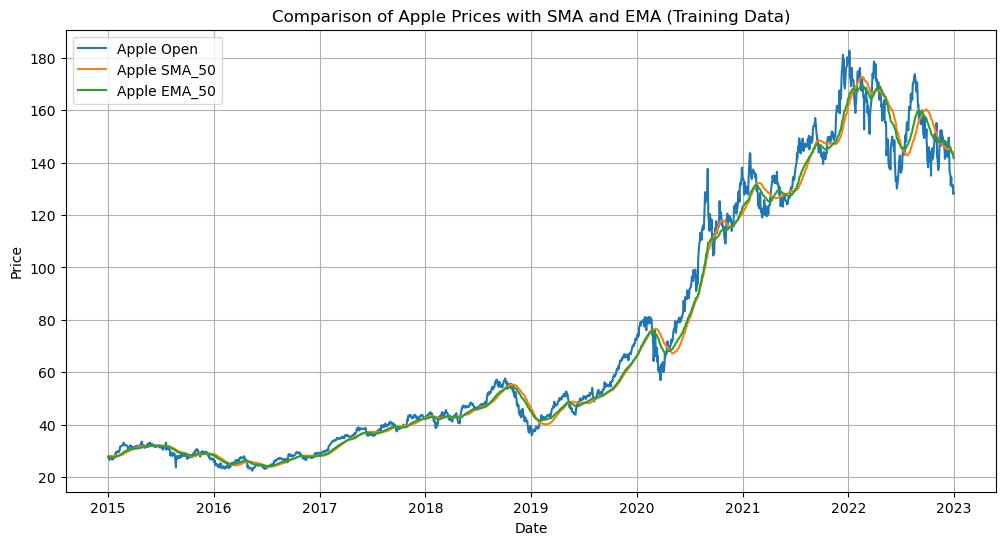

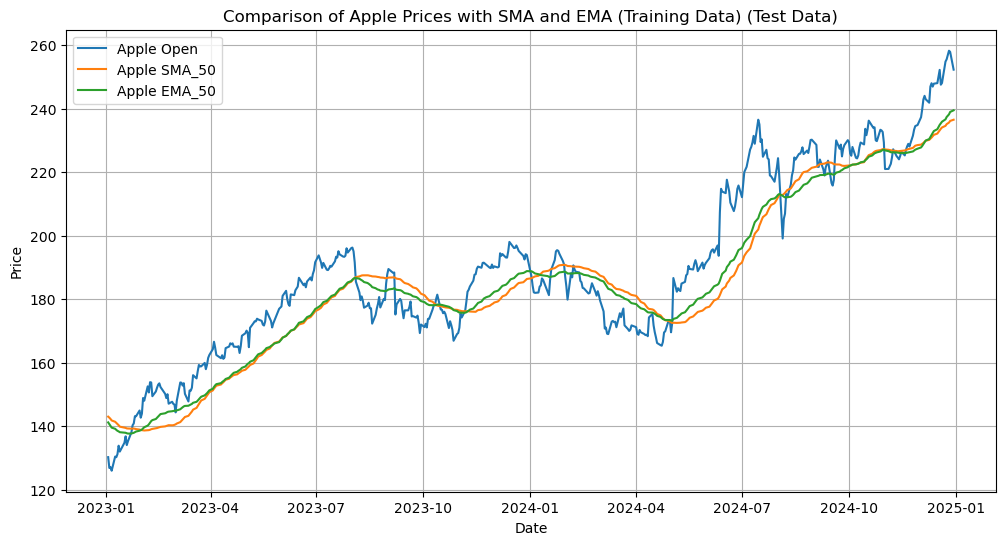

In [15]:
# Сравнение внутри компании (с SMA и EMA) для тренировочных и тестовых данных
process_multiple_instances(
    instances=[train_visualizer, test_visualizer],
    method_name='plot_aggregated',
    companies=[NAME],
    targets=[TARGET, f'SMA_50', f'EMA_50'],
    title=f"Comparison of {NAME.capitalize()} Prices with SMA and EMA",
    ylabel="Price"
)

На основе данных графиков сделаем небольшие выводы.

---

**График 1: Тренировочные данные (Train)**

На графике представлены **цены открытия акций компании Apple** с наложением скользящих средних (SMA_50 и EMA_50) за тренировочный период (2015–2022 годы).

**1. Общие выводы по трендам:**
- Основная тенденция демонстрирует **устойчивый рост цен открытия акций Apple** с 2015 года.
- Визуально кажется, что волатильность ниже, чем на тестовых данных, но это связано с увеличенным временным промежутком, который сглаживает колебания.
- SMA_50 и EMA_50 хорошо следуют за общим трендом, выделяя долгосрочные тенденции, при этом EMA немного быстрее реагирует на изменения.

**2. Анализ сглаживания:**
- **SMA_50** и **EMA_50** идут близко друг к другу, что свидетельствует о стабильных изменениях цен.
- Отклонения между SMA/EMA и ценой акций минимальны на протяжении всего периода, благодаря долгосрочному масштабу анализа.

---

**График 2: Тестовые данные (Test)**

На графике представлены **цены открытия акций компании Apple** с наложением скользящих средних (SMA_50 и EMA_50) за тестовый период (2023–2024 годы).

**1. Общие выводы по трендам:**
- Тестовые данные охватывают более короткий временной промежуток, что делает колебания цен более заметными.
- Волатильность цен открытия кажется выше, но это связано с масштабом графика и меньшим периодом анализа.
- SMA_50 и EMA_50 продолжают эффективно следовать за трендом, поддерживая общую структуру данных.

**2. Анализ сглаживания:**
- **SMA_50** и **EMA_50** также расположены близко друг к другу, демонстрируя стабильность в расчёте средних.
- Отклонения цены от SMA_50 и EMA_50 немного больше по сравнению с тренировочными данными, что связано с увеличением цен и большей детализацией на меньшем временном отрезке.

---

**Заключение:**
- Различия между тренировочными и тестовыми графиками в основном связаны с временными масштабами: тренировочные данные охватывают 8 лет, а тестовые — всего 2 года.
- Поведение SMA_50 и EMA_50 остаётся стабильным на обоих графиках, а их близость друг к другу подтверждает надёжность этих индикаторов.

---

Далее рассмотрим данные за одинаковые временные промежутки (последние 2 года), однако на этот раз используем скользящие средние (SMA и EMA) с меньшим периодом — всего 10 дней. Это позволит более подробно рассмотреть локальные изменения и колебания цен.


In [ ]:
# График за последние 2 года с SMA, EMA и объёмом торгов на тренировочных и на тестовых данных
process_multiple_instances(
    instances=[train_visualizer, test_visualizer],
    method_name='plot_last_years',
    companies=[NAME],
    targets=[TARGET, f'SMA_10', f'EMA_10'],
    years = 2
)

На основе данных графиков сделаем небольшие выводы.

---

**График 1: Тренировочные данные (Train)**

На графике представлены **цены открытия акций компании Apple** с наложением скользящих средних (SMA и EMA) за 10 дней для тренировочной выборки (2021–2023 годы).

**1. Общие выводы по трендам:**
- Основная тенденция демонстрирует **чередование роста и спада цен открытия акций** в течение двухлетнего периода.
- Ярко выражены периоды падения цен (например, в 2022 году), что свидетельствует о локальных рыночных коррекциях.
- Волатильность цен заметно увеличивается в периоды коррекций, что соответствует ожидаемому поведению рынка.

**2. Анализ сглаживания:**
- **SMA** и **EMA** эффективно следуют за общими трендами, показывая более сглаженную картину изменений.
- Различия между SMA и EMA минимальны при использовании периода в 10 дней, но EMA реагирует быстрее на изменения, выделяя краткосрочные колебания.

---

**График 2: Тестовые данные (Test)**

На графике представлены **цены открытия акций компании Apple** с наложением скользящих средних (SMA и EMA) за 10 дней для тестовой выборки (2023–2025 годы).

**1. Общие выводы по трендам:**
- Тестовые данные демонстрируют **постепенный рост цен открытия акций**, особенно в последней половине 2024 года.
- Периоды повышенной волатильности видны в середине 2023 года, но к концу периода тренд становится более устойчивым.
- Скользящие средние четко отражают общий восходящий тренд, подтверждая, что рынок восстанавливается после локальных спадов.

**2. Анализ сглаживания:**
- **SMA** и **EMA** продолжают эффективно выполнять свою задачу, выделяя основные тренды и исключая краткосрочные шумы.
- EMA, как и на тренировочных данных, быстрее реагирует на изменения, что делает её более подходящей для анализа в условиях повышенной волатильности.

---

**Общие наблюдения:**
Сравнение двух графиков показывает, что тестовые данные содержат больше периодов устойчивого роста, в то время как тренировочные данные демонстрируют более выраженные колебания. Использование SMA и EMA помогает упростить анализ и выделить ключевые тренды для обеих выборок.


In [ ]:
# visualizer.plot_with_secondary_axis(company=NAME, target=TARGET, sma_period=10, ema_period=10, 
#                                      secondary_metric="Volatility", secondary_axis=True)

In [ ]:
# visualizer.plot_with_secondary_axis(company=NAME, target=TARGET, sma_period=10, ema_period=10, 
#                                      secondary_metric="Volume", secondary_axis=True)

## Обучение
### Functions

In [ ]:
def optimize_df(df):
    """Уменьшение размерности датафрейма"""
    initial_memory = df.memory_usage(deep=True).sum()
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type == 'float64' or col_type == 'float32':
            # Проверяем, можно ли привести float к int
            if df[col].apply(float.is_integer).all():
                df[col] = pd.to_numeric(df[col], downcast='integer')
            else:
                df[col] = pd.to_numeric(df[col], downcast='float')
        
        elif col_type == 'int64' or col_type == 'int32':
            df[col] = pd.to_numeric(df[col], downcast='integer')
        
        elif col_type == 'object':
            num_unique_values = len(df[col].unique())
            num_total_values = len(df[col])
            if num_unique_values / num_total_values < 0.5:
                df[col] = df[col].astype('category')
        
        elif col_type == 'bool':
            df[col] = df[col].astype('int8')
    
    final_memory = df.memory_usage(deep=True).sum()
    memory_reduction = (initial_memory - final_memory) / initial_memory * 100
    
    print(f"Память до оптимизации: {initial_memory} байт")
    print(f"Память после оптимизации: {final_memory} байт")
    print(f"Сокращение памяти: {memory_reduction:.2f}%")
    
    return df

In [ ]:
def plot_feature_importances(model, feature_names, model_name):
    """
    Функция для вывода важности признаков для модели.

    Parameters:
    model (sklearn model): Обученная модель.
    feature_names (list): Список названий признаков.
    model_name (str): Название модели.
    """
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        importances = model.coef_
    else:
        raise ValueError(f"Model {model_name} does not have feature importances or coefficients.")

    # Создание DataFrame для удобного отображения
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
    
    # Построение графика
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
    plt.title(f'Feature Importances for best model - {model_name}')
    plt.show()

### Подготовка к обучению

### Train

## Выбор лучшей модели

## Выводы